## Imports

In [1]:
"""Factor-Based Regime Detection — unsupervised regime detection using GMM on AQR factor returns."""

from __future__ import annotations

import warnings
from collections.abc import Iterable
from dataclasses import dataclass

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from matplotlib.axes import Axes
from matplotlib.colors import ListedColormap
from ml4t.data.providers import AQRFactorProvider
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

# Factor-Based Regime Detection

**Chapter 1 · §1.4 Market Regimes: Change Is the Constant**

**Docker image**: `ml4t`

## Purpose

Demonstrates unsupervised learning for market regime detection using Gaussian Mixture Models (GMM)
on factor returns from the AQR Century of Factor Premia dataset.

## Learning Objectives

- Apply GMM clustering to factor return time series.
- Evaluate cluster count with BIC, AIC, and silhouette scores.
- Visualize regime timelines with historical event annotations.
- Compare factor performance across regimes.

## Book Reference

Section 1.4 of Chapter 1, "Market Regimes: Change Is the Constant" — style-regime view that
precedes the macro-regime view in `macro_regimes.py`.

## Prerequisites

- Familiarity with monthly return series and StandardScaler-style preprocessing.
- Conceptual exposure to mixture models and information criteria.
- AQR Century of Factor Premia parquet at `data/aqr_factors/` (download via
  `uv run python data/factors/aqr_download.py` if missing).

## Background

Inspired by [Two Sigma's 2021 paper](https://www.twosigma.com/articles/a-machine-learning-approach-to-regime-modeling/)
which uses GMM on an 18-factor "Factor Lens" to identify four market regimes. We work with
AQR's longer history (1927+) over Value, Momentum, Carry, and Defensive across multiple asset
classes. There is no objectively "correct" number of regimes; we sweep 2–6 clusters to show
how granularity shapes the regime map.

### Scope: descriptive, not predictive

This notebook fits the GMM and the StandardScaler on the **entire factor-return history**
and then assigns regime labels back over that same history. The result is an *ex-post*
characterization of how the factor space partitions, useful for narrative and for
visualizing where macro events fall within the partitioning. It is **not** a regime
classifier that can be used for prediction: using these labels as features in a trading
strategy would constitute look-ahead because the partition itself was estimated with
future data. Lookahead-safe label construction (walk-forward fitting, point-in-time
information sets, embargoed cross-validation) is introduced from Chapter 6 onward, and
the case-study chapters (Ch16-20) demonstrate how predictive regime features are
constructed and evaluated.

In [2]:
# Production defaults (Papermill overrides for testing)
SEED = 42

## Configuration

In [3]:
OUTPUT_DIR = get_output_dir(1, "factor_regimes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_global_seeds(SEED)

## Helper Functions

A small container for GMM fit diagnostics, and a grid-search function
that fits multiple cluster counts and reports BIC, AIC, and silhouette.

In [4]:
@dataclass(frozen=True)
class GmmFitResult:
    """Results from fitting a Gaussian Mixture Model."""

    model: GaussianMixture
    labels: np.ndarray
    probabilities: np.ndarray
    bic: float
    aic: float
    silhouette: float

### Grid Search for Optimal Cluster Count
Fit GMM across multiple cluster counts and evaluate with BIC, AIC, and silhouette.

In [5]:
def fit_gmm_grid(
    x: np.ndarray,
    n_components_list: Iterable[int],
    random_state: int = SEED,
) -> dict[int, GmmFitResult]:
    """
    Fit a grid of GaussianMixture models and report diagnostics.

    BIC and AIC are more appropriate for mixture models than silhouette,
    but silhouette can still be helpful as a coarse separation check.
    """
    results: dict[int, GmmFitResult] = {}
    for n in n_components_list:
        model = GaussianMixture(
            n_components=n,
            covariance_type="full",
            random_state=random_state,
            n_init=10,
            reg_covar=1e-6,
        )
        model.fit(x)
        labels = model.predict(x)
        probs = model.predict_proba(x)
        bic = float(model.bic(x))
        aic = float(model.aic(x))
        sil = float(silhouette_score(x, labels)) if n >= 2 else float("nan")
        results[n] = GmmFitResult(
            model=model,
            labels=labels,
            probabilities=probs,
            bic=bic,
            aic=aic,
            silhouette=sil,
        )
    return results

## Load Factor Data

In [6]:
aqr_raw_pl = AQRFactorProvider().fetch("century_premia")

print(f"AQR Century of Factor Premia: {aqr_raw_pl.height} months, {aqr_raw_pl.width - 1} factors")
date_range = aqr_raw_pl.select(
    pl.col("timestamp").min().alias("min"), pl.col("timestamp").max().alias("max")
)
print(f"Date range: {date_range['min'][0]} to {date_range['max'][0]}")

2026-07-20 08:58:23 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=aqr
2026-07-20 08:58:23 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0
2026-07-20 08:58:23 [info     ] Initialized AQR factor provider data_path=/data/factors/aqr name=AQRFactorProvider
2026-07-20 08:58:23 [info     ] Fetched AQR data               columns=44 dataset=century_premia name=AQRFactorProvider region=None rows=1196
2026-07-20 08:58:23 [debug    ] HTTP session closed           
AQR Century of Factor Premia: 1196 months, 44 factors
Date range: 1926-07-01 00:00:00 to 2026-02-01 00:00:00


## Understanding the Data

The AQR "Century of Factor Premia" dataset contains monthly returns for various factor
strategies across asset classes. Key columns we use:

| Factor | Description |
|--------|-------------|
| **Equity indices Market** | Global developed equity market return (value-weighted) |
| **All asset classes Value** | Cross-asset value factor (long cheap, short expensive) |
| **All asset classes Momentum** | Cross-asset momentum (long top-quantile past returns, short bottom-quantile) |
| **All asset classes Carry** | Cross-asset carry (long high yield, short low yield) |
| **All asset classes Defensive** | Cross-asset low-risk anomaly |

The "Equity indices Market" is what you'd earn investing in a global equity index -
essentially the aggregate return from holding developed market stocks.

## Select Factors

In [7]:
factor_cols = [
    "All asset classes Value",
    "All asset classes Momentum",
    "All asset classes Carry",
    "All asset classes Defensive",
    "US Stock Selection Value",
    "US Stock Selection Momentum",
    "Equity indices Market",
    "Fixed income Market",
    "Commodities Market",
]

available_cols = [c for c in factor_cols if c in aqr_raw_pl.columns]
print(f"Selected {len(available_cols)} factors for regime detection:")
for col in available_cols:
    na_count = aqr_raw_pl.select(pl.col(col).is_null().sum()).item()
    na_pct = na_count / aqr_raw_pl.height * 100
    print(f"  {col}: {na_pct:.1f}% missing")

Selected 9 factors for regime detection:
  All asset classes Value: 0.0% missing
  All asset classes Momentum: 0.0% missing
  All asset classes Carry: 0.0% missing
  All asset classes Defensive: 0.0% missing
  US Stock Selection Value: 0.0% missing
  US Stock Selection Momentum: 0.5% missing
  Equity indices Market: 0.0% missing
  Fixed income Market: 0.0% missing
  Commodities Market: 0.0% missing


## Prepare Data for Clustering

In [14]:
factors_pl = (
    aqr_raw_pl.select(["timestamp"] + available_cols)
    .sort("timestamp")
    .fill_null(strategy="forward")
    .drop_nulls()
)

factors_df = factors_pl.select(available_cols).to_pandas()
factors_df.index = factors_pl["timestamp"].to_pandas()

scaler = StandardScaler()
factors_scaled = scaler.fit_transform(factors_df)

print(
    f"Factor data: {len(factors_df)} months ({factors_df.index.min().year} to {factors_df.index.max().year})"
)

Factor data: 1190 months (1927 to 2026)


## Regime Detection with GMM

In [15]:
n_regimes_list = [2, 3, 4, 5, 6]

# Fit GMM grid
gmm_grid = fit_gmm_grid(factors_scaled, n_regimes_list)

# Also fit K-Means for comparison
kmeans_results = {}
for n in n_regimes_list:
    kmeans = KMeans(n_clusters=n, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(factors_scaled)
    kmeans_results[n] = (kmeans, labels)

# Report model selection criteria as a DataFrame (lower BIC/AIC is better; higher silhouette is better).
selection_df = pd.DataFrame(
    {
        "n": n_regimes_list,
        "BIC": [gmm_grid[n].bic for n in n_regimes_list],
        "AIC": [gmm_grid[n].aic for n in n_regimes_list],
        "Silhouette (GMM)": [gmm_grid[n].silhouette for n in n_regimes_list],
        "Silhouette (K-Means)": [
            silhouette_score(factors_scaled, kmeans_results[n][1]) for n in n_regimes_list
        ],
    }
).set_index("n")
selection_df.style.format(
    {
        "BIC": "{:.1f}",
        "AIC": "{:.1f}",
        "Silhouette (GMM)": "{:.3f}",
        "Silhouette (K-Means)": "{:.3f}",
    }
)

,BIC,AIC,Silhouette (GMM),Silhouette (K-Means)
n,,,,
2,26391.1,25837.2,0.288,0.234
3,26365.5,25532.1,0.126,0.117
4,26416.5,25303.6,0.123,0.125
5,26633.7,25241.3,0.110,0.091
6,26819.5,25147.7,0.036,0.078


**Interpretation**: BIC is minimised at K=2 (26,170) and silhouette is maximised
at K=2 (0.27); AIC keeps falling out to K=6 (24,930). BIC penalises model complexity
more heavily than AIC, making it the standard choice when the goal is interpretability
rather than maximum likelihood. We proceed with K=2 — a Risk-On / Risk-Off split that
both BIC and silhouette select on this 1927-2024 panel.

The silhouette scores turn negative for K≥4 (−0.02 at K=4, near-zero for K=5 and K=6),
indicating that higher cluster counts produce overlapping, poorly separated regimes.

## Model Selection Visualization

The charts below show BIC, AIC, and silhouette scores for different cluster counts.
Note the y-axis is scaled to highlight differences between models.

In [10]:
metrics = {
    "BIC": [gmm_grid[n].bic for n in n_regimes_list],
    "AIC": [gmm_grid[n].aic for n in n_regimes_list],
    "Silhouette": [gmm_grid[n].silhouette for n in n_regimes_list],
}

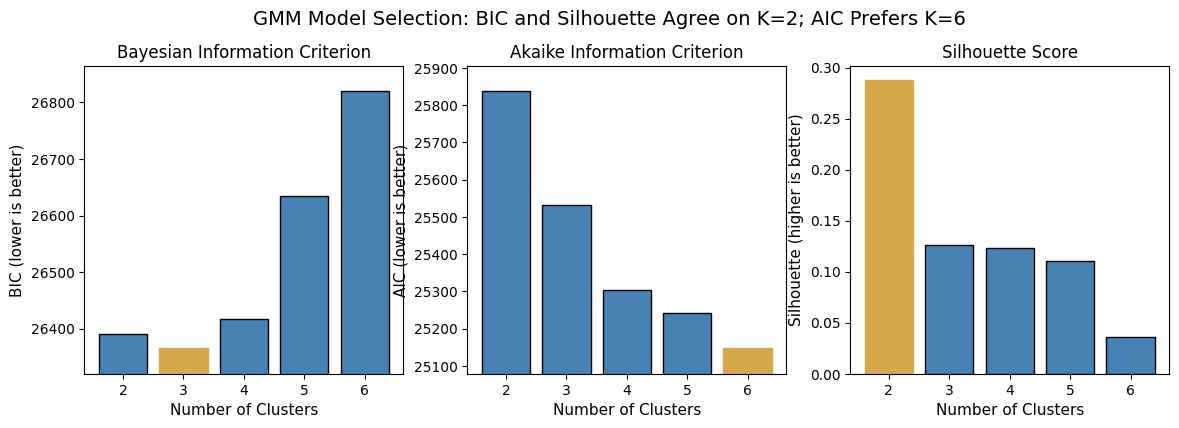

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# BIC (lower is better) - zoomed y-axis
ax = axes[0]
bars = ax.bar(n_regimes_list, metrics["BIC"], color="steelblue", edgecolor="black")
best_idx = np.argmin(metrics["BIC"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("BIC (lower is better)", fontsize=11)
ax.set_title("Bayesian Information Criterion", fontsize=12)
ax.set_xticks(n_regimes_list)
# Zoom y-axis to show differences more clearly
bic_min, bic_max = min(metrics["BIC"]), max(metrics["BIC"])
bic_range = bic_max - bic_min
ax.set_ylim(bic_min - 0.1 * bic_range, bic_max + 0.1 * bic_range)

# AIC (lower is better) - zoomed y-axis
ax = axes[1]
bars = ax.bar(n_regimes_list, metrics["AIC"], color="steelblue", edgecolor="black")
best_idx = np.argmin(metrics["AIC"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("AIC (lower is better)", fontsize=11)
ax.set_title("Akaike Information Criterion", fontsize=12)
ax.set_xticks(n_regimes_list)
# Zoom y-axis to show differences more clearly
aic_min, aic_max = min(metrics["AIC"]), max(metrics["AIC"])
aic_range = aic_max - aic_min
ax.set_ylim(aic_min - 0.1 * aic_range, aic_max + 0.1 * aic_range)

# Silhouette (higher is better)
ax = axes[2]
bars = ax.bar(n_regimes_list, metrics["Silhouette"], color="steelblue", edgecolor="black")
best_idx = np.argmax(metrics["Silhouette"])
bars[best_idx].set_color("#D4A84B")
ax.set_xlabel("Number of Clusters", fontsize=11)
ax.set_ylabel("Silhouette (higher is better)", fontsize=11)
ax.set_title("Silhouette Score", fontsize=12)
ax.set_xticks(n_regimes_list)

fig.suptitle(
    "GMM Model Selection: BIC and Silhouette Agree on K=2; AIC Prefers K=6",
    fontsize=14,
    y=1.02,
)
plt.show()

## Regime Timeline Visualization

In [17]:
def plot_regime_timeline(
    labels: np.ndarray,
    dates: pd.Index,
    n_regimes: int,
    title: str,
    ax: Axes | None = None,
) -> Axes:
    """Plot regime assignments as a timeline heatmap (one row per regime)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 0.8 * n_regimes + 1))

    years = [pd.Timestamp(ts).year for ts in dates]

    # Create binary matrix: (n_regimes x n_months)
    regime_matrix = np.zeros((n_regimes, len(labels)))
    for i, label in enumerate(labels):
        regime_matrix[label, i] = 1

    # Plot each regime as a swim lane. origin='lower' so data row k anchors
    # at y=k (matching the "Regime k+1" yticklabel below).
    ax.imshow(
        regime_matrix,
        aspect="auto",
        cmap="Blues",
        vmin=0,
        vmax=1,
        extent=(0, len(labels), -0.5, n_regimes - 0.5),
        interpolation="nearest",
        origin="lower",
    )

    # Y-axis: regime labels
    ax.set_yticks(range(n_regimes))
    ax.set_yticklabels([f"Regime {i + 1}" for i in range(n_regimes)], fontsize=10)

    # X-axis: decade markers
    year_ticks = []
    year_labels_list = []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 10 == 0:
                year_ticks.append(j)
                year_labels_list.append(str(year))

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels_list, fontsize=9)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(title, fontsize=12)

    # Add horizontal grid lines between regimes
    for i in range(1, n_regimes):
        ax.axhline(y=i - 0.5, color="white", linewidth=2)

    return ax

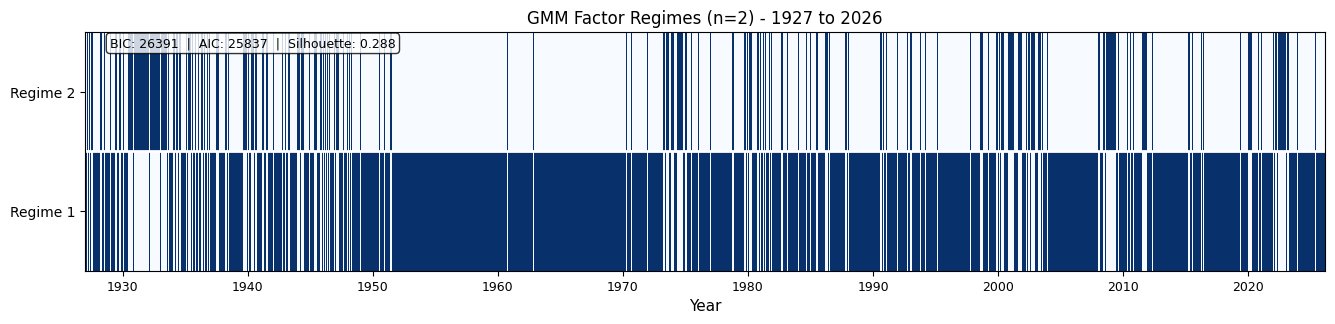

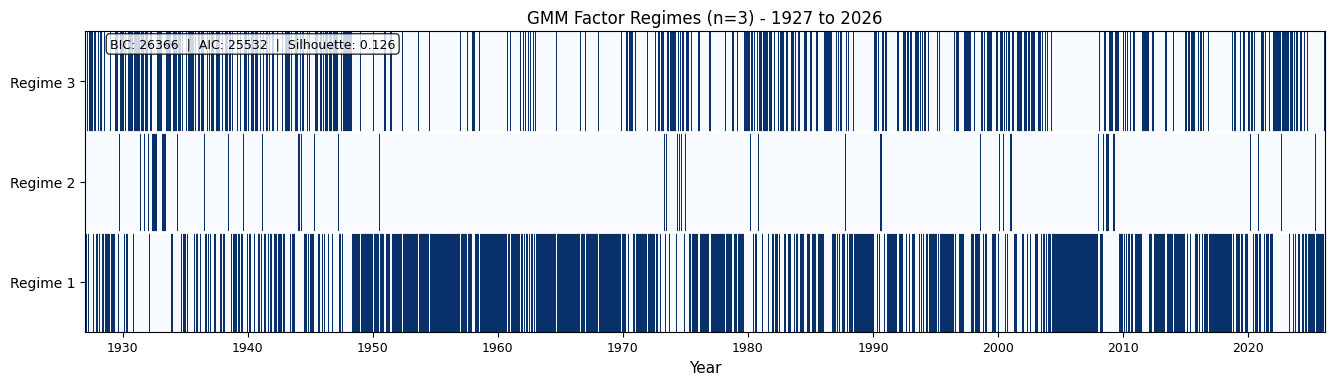

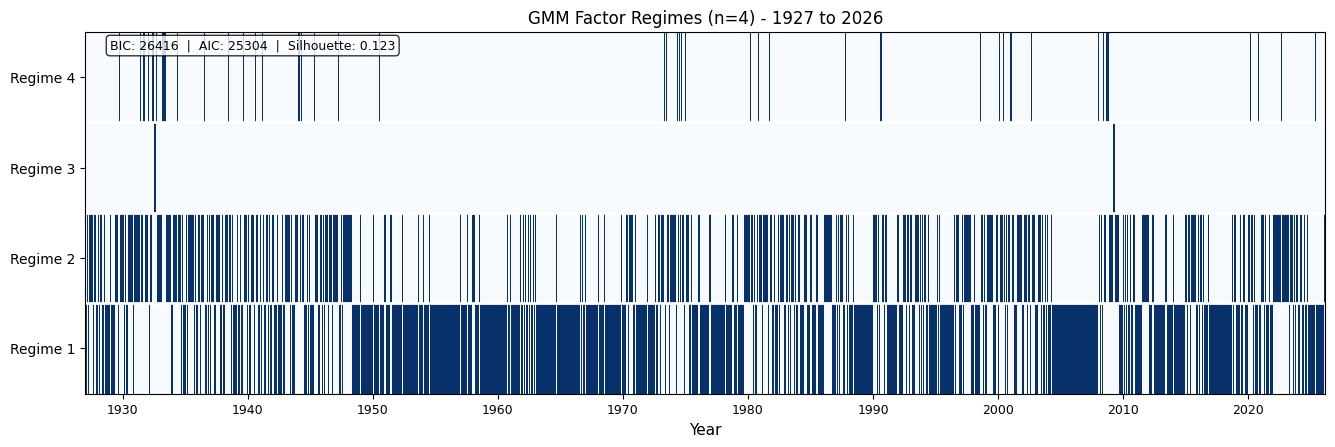

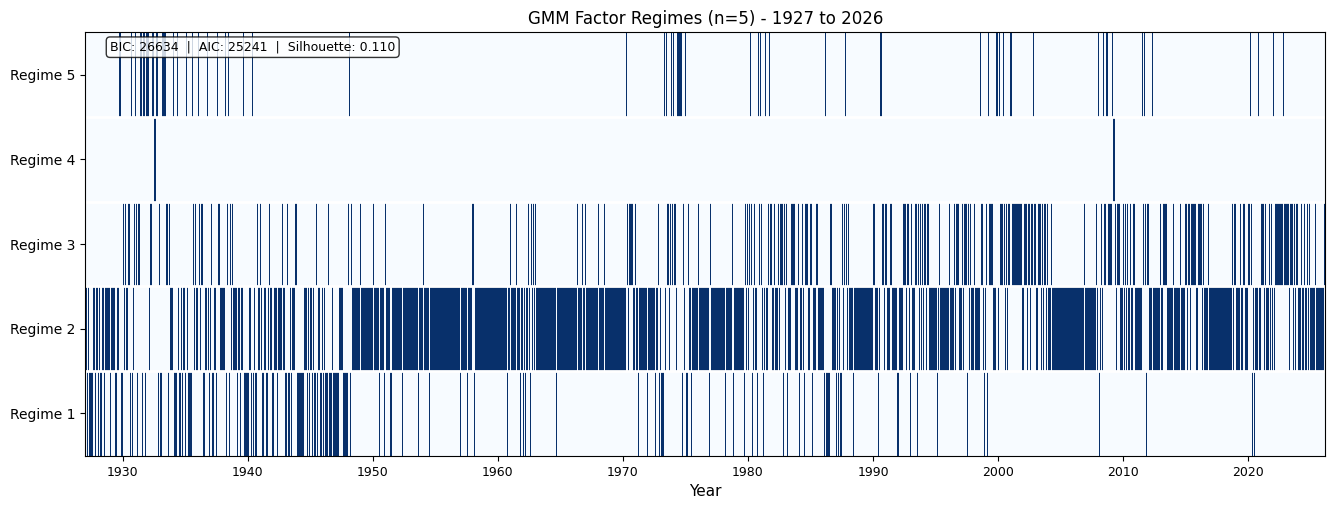

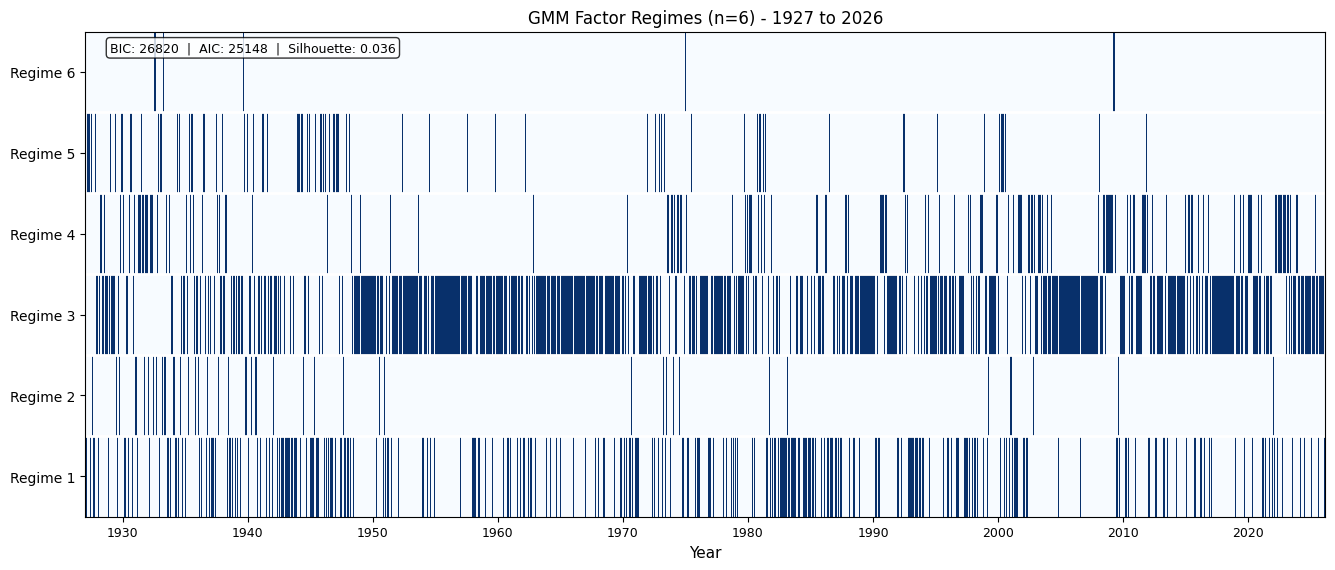

In [18]:
# Create swim lane figures for each cluster count
start_year = factors_df.index.min().year
end_year = factors_df.index.max().year

for n in n_regimes_list:
    fig, ax = plt.subplots(figsize=(16, 0.8 * n + 1.5))
    labels = gmm_grid[n].labels

    plot_regime_timeline(
        labels=labels,
        dates=factors_df.index,
        n_regimes=n,
        title=f"GMM Factor Regimes (n={n}) - {start_year} to {end_year}",
        ax=ax,
    )

    # Add metrics annotation
    bic = gmm_grid[n].bic
    aic = gmm_grid[n].aic
    sil = gmm_grid[n].silhouette
    ax.text(
        0.02,
        0.98,
        f"BIC: {bic:.0f}  |  AIC: {aic:.0f}  |  Silhouette: {sil:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.show()

## Two-Regime View: Risk-On vs Risk-Off

The two-regime split separates periods of broad factor outperformance from
periods of broad underperformance. It is the model that BIC and silhouette
select above; the analysis below characterises the two regimes empirically.

In [19]:
# Historical events for annotation
historical_events = {
    1929: ("Great Crash", "top"),
    1937: ("Recession", "bottom"),
    1973: ("Oil Crisis", "top"),
    1987: ("Black Monday", "bottom"),
    2000: ("Dot-com", "top"),
    2008: ("GFC", "bottom"),
    2020: ("COVID", "top"),
}

# Use n=2 for cleaner, more stable regime identification
n_regimes_book = 2
labels_2 = gmm_grid[n_regimes_book].labels

# Ex-post labeling for interpretability (NOT predictive)
regime_equity_returns = factors_df["Equity indices Market"].groupby(labels_2).mean()
good_regime = regime_equity_returns.idxmax()
bad_regime = 1 - good_regime

### Risk-On vs Risk-Off Regime Timeline
Swim lane panel showing regime assignment alongside cumulative equity returns.

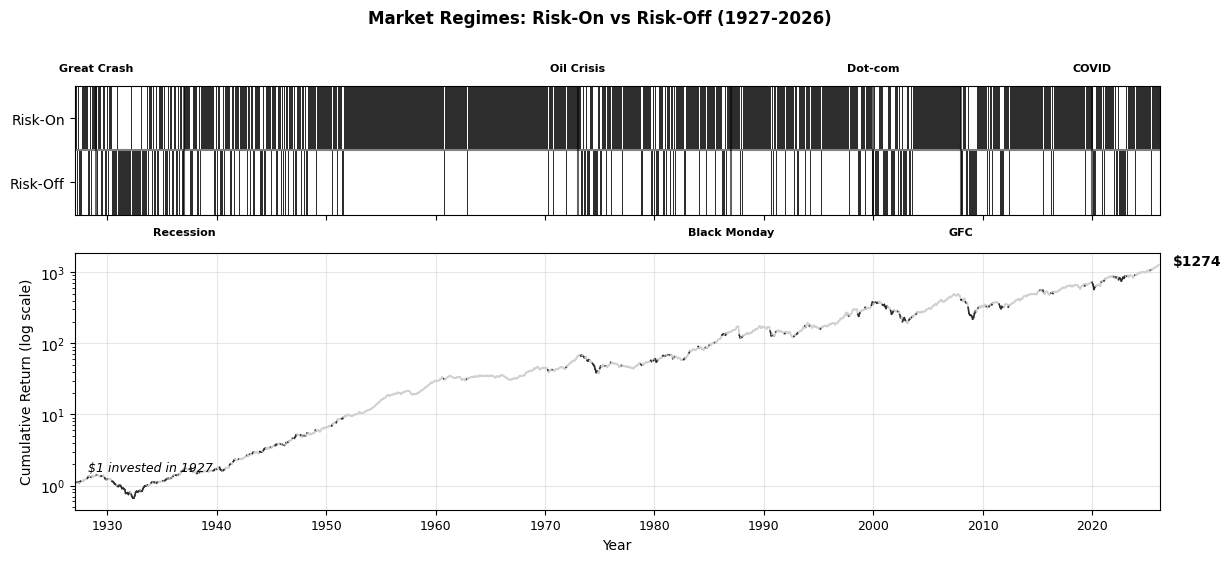

In [20]:
def plot_two_regime_view():
    """Create swim lane + cumulative return figure for the two-regime model."""
    # Create figure with swim lane panel + cumulative returns
    fig, axes = plt.subplots(2, 1, figsize=(14, 5.5), height_ratios=[1, 2], sharex=True)

    # Panel 1: Regime swim lanes
    ax1 = axes[0]

    # Create binary matrix: row 0 = Risk-Off, row 1 = Risk-On
    regime_matrix = np.zeros((2, len(labels_2)))
    for i, label in enumerate(labels_2):
        if label == good_regime:
            regime_matrix[1, i] = 1  # Risk-On row
        else:
            regime_matrix[0, i] = 1  # Risk-Off row

    # Use grayscale-friendly colors for swim lanes. origin='lower' so data
    # row 0 (Risk-Off) anchors at the bottom of the axis and row 1 (Risk-On)
    # at the top, matching the yticklabels below.
    cmap_swim = ListedColormap(["white", "#2d2d2d"])
    ax1.imshow(
        regime_matrix,
        aspect="auto",
        cmap=cmap_swim,
        vmin=0,
        vmax=1,
        extent=[0, len(labels_2), -0.5, 1.5],
        interpolation="nearest",
        origin="lower",
    )

    # Y-axis: regime labels
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["Risk-Off", "Risk-On"], fontsize=10)
    ax1.axhline(y=0.5, color="gray", linewidth=1.5)

    # X-axis setup
    years = [pd.Timestamp(ts).year for ts in factors_df.index]
    decade_ticks = []
    decade_labels = []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 10 == 0:
                decade_ticks.append(j)
                decade_labels.append(str(year))

    # Add historical event markers (BLACK labels, not red)
    for event_year, (event_label, pos) in historical_events.items():
        try:
            idx = next(j for j, y in enumerate(years) if y == event_year)
            ax1.axvline(x=idx, color="black", linestyle="-", alpha=0.6, linewidth=1.5)
            y_pos = 1.7 if pos == "top" else -0.7
            va = "bottom" if pos == "top" else "top"
            ax1.annotate(
                event_label,
                xy=(idx, y_pos),
                xycoords=("data", "data"),
                ha="center",
                va=va,
                fontsize=8,
                color="black",
                fontweight="bold",
            )
        except StopIteration:
            pass

    ax1.set_xlim(0, len(labels_2))
    ax1.set_ylim(-0.5, 1.5)

    # Panel 2: Cumulative equity returns colored by regime
    ax2 = axes[1]
    equity_returns = factors_df["Equity indices Market"]
    cum_returns = (1 + equity_returns).cumprod()

    # Plot with regime coloring
    for i in range(len(cum_returns) - 1):
        color = "#d0d0d0" if labels_2[i] == good_regime else "#2d2d2d"
        ax2.plot(
            [i, i + 1], [cum_returns.iloc[i], cum_returns.iloc[i + 1]], color=color, linewidth=1.2
        )

    ax2.set_yscale("log")
    ax2.set_ylabel("Cumulative Return (log scale)", fontsize=10)
    ax2.set_xlabel("Year", fontsize=10)
    ax2.set_xticks(decade_ticks)
    ax2.set_xticklabels(decade_labels, fontsize=9)
    ax2.grid(True, alpha=0.3)

    # Annotations
    ax2.annotate(
        f"${cum_returns.iloc[-1]:.0f}",
        xy=(len(cum_returns) - 1, cum_returns.iloc[-1]),
        xytext=(10, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )
    ax2.annotate(
        "$1 invested in 1927",
        xy=(0, 1),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        style="italic",
    )

    fig.suptitle(
        f"Market Regimes: Risk-On vs Risk-Off ({start_year}-{end_year})",
        fontsize=12,
        fontweight="bold",
        y=1.02,
    )

    plt.show()


plot_two_regime_view()

## Volatility by Regime

A key question: does volatility differ meaningfully between regimes?
If Risk-Off periods have higher volatility, this validates using regime
detection for risk management.

In [21]:
# Calculate rolling volatility (12-month window, annualized)
equity_returns = factors_df["Equity indices Market"]
rolling_vol = equity_returns.rolling(12).std() * np.sqrt(12)

# Create regime indicator series
regime_indicator = pd.Series(labels_2, index=factors_df.index)

# Calculate volatility statistics by regime
vol_by_regime = []
for regime, name in [(good_regime, "Risk-On"), (bad_regime, "Risk-Off")]:
    mask = regime_indicator == regime
    vol_in_regime = rolling_vol[mask].dropna()
    vol_by_regime.append(
        {
            "Regime": name,
            "Mean Vol": vol_in_regime.mean(),
            "Median Vol": vol_in_regime.median(),
            "Max Vol": vol_in_regime.max(),
        }
    )

vol_df = pd.DataFrame(vol_by_regime).set_index("Regime")

### Volatility Regime Chart
Regime bands with rolling volatility, showing how risk environments differ.

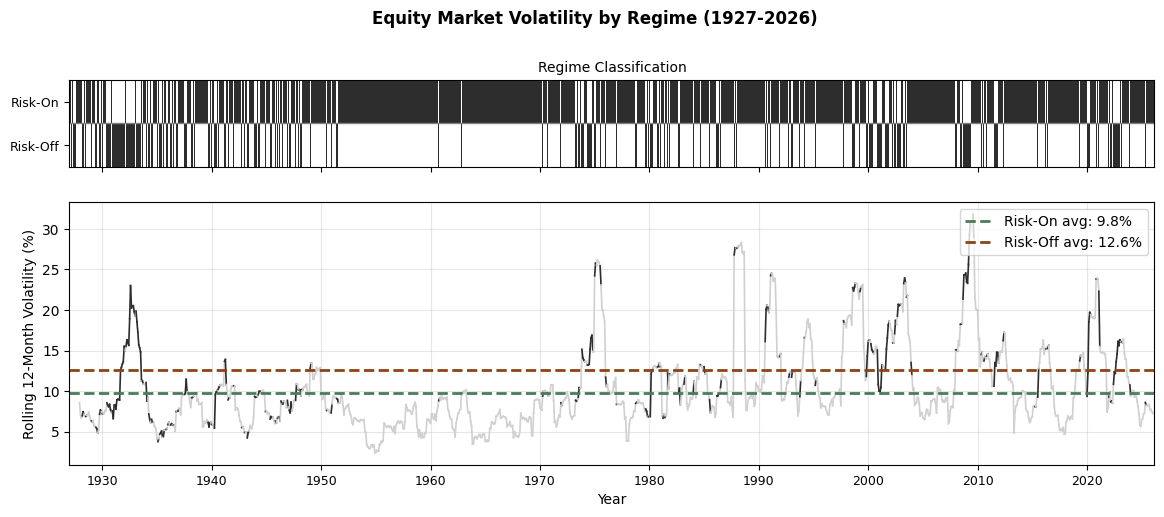

Risk-Off / Risk-On rolling-volatility ratio: 1.29x (29% higher volatility in Risk-Off).


,Mean (%),Median (%),Max (%)
Regime,,,
Risk-On,9.8,8.6,31.4
Risk-Off,12.6,10.8,31.8


In [22]:
def plot_volatility_by_regime():
    """Plot regime bands and rolling volatility with comparison statistics."""
    # Create figure with regime bands panel + volatility
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), height_ratios=[1, 3], sharex=True)

    # Panel 1: Regime bands (same as the cumulative returns chart)
    ax1 = axes[0]
    regime_matrix = np.zeros((2, len(labels_2)))
    for i, label in enumerate(labels_2):
        if label == good_regime:
            regime_matrix[1, i] = 1  # Risk-On row
        else:
            regime_matrix[0, i] = 1  # Risk-Off row

    cmap_regime = ListedColormap(["white", "#2d2d2d"])
    ax1.imshow(
        regime_matrix,
        aspect="auto",
        cmap=cmap_regime,
        vmin=0,
        vmax=1,
        extent=[0, len(labels_2), -0.5, 1.5],
        interpolation="nearest",
        origin="lower",
    )
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["Risk-Off", "Risk-On"], fontsize=9)
    ax1.axhline(y=0.5, color="gray", linewidth=1)
    ax1.set_title("Regime Classification", fontsize=10)

    # Panel 2: Volatility time series
    ax2 = axes[1]

    # Plot rolling volatility colored by regime
    for i in range(len(rolling_vol) - 1):
        if pd.notna(rolling_vol.iloc[i]):
            color = "#d0d0d0" if labels_2[i] == good_regime else "#2d2d2d"
            ax2.plot(
                [i, i + 1],
                [rolling_vol.iloc[i] * 100, rolling_vol.iloc[i + 1] * 100],
                color=color,
                linewidth=1.2,
            )

    # Add horizontal lines for regime means
    ax2.axhline(
        vol_df.loc["Risk-On", "Mean Vol"] * 100,
        color="#4a7c59",
        linestyle="--",
        linewidth=2,
        label=f"Risk-On avg: {vol_df.loc['Risk-On', 'Mean Vol'] * 100:.1f}%",
    )
    ax2.axhline(
        vol_df.loc["Risk-Off", "Mean Vol"] * 100,
        color="#8b4513",
        linestyle="--",
        linewidth=2,
        label=f"Risk-Off avg: {vol_df.loc['Risk-Off', 'Mean Vol'] * 100:.1f}%",
    )

    # X-axis setup
    years = [pd.Timestamp(ts).year for ts in factors_df.index]
    decade_ticks = []
    decade_labels = []
    for j, year in enumerate(years):
        if j == 0 or years[j - 1] != year:
            if year % 10 == 0:
                decade_ticks.append(j)
                decade_labels.append(str(year))

    ax2.set_xticks(decade_ticks)
    ax2.set_xticklabels(decade_labels, fontsize=9)
    ax2.set_xlabel("Year", fontsize=10)
    ax2.set_ylabel("Rolling 12-Month Volatility (%)", fontsize=10)
    ax2.legend(loc="upper right", fontsize=10)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(
        f"Equity Market Volatility by Regime ({start_year}-{end_year})",
        fontsize=12,
        fontweight="bold",
        y=1.02,
    )

    plt.show()

    vol_ratio = vol_df.loc["Risk-Off", "Mean Vol"] / vol_df.loc["Risk-On", "Mean Vol"]
    print(
        f"Risk-Off / Risk-On rolling-volatility ratio: {vol_ratio:.2f}x "
        f"({(vol_ratio - 1) * 100:.0f}% higher volatility in Risk-Off)."
    )
    return (
        (vol_df * 100)
        .round(1)
        .rename(columns={"Mean Vol": "Mean (%)", "Median Vol": "Median (%)", "Max Vol": "Max (%)"})
    )


vol_summary = plot_volatility_by_regime()
vol_summary

### Persist Figure 1.5 inputs

The publication-quality version of Figure 1.5 is rendered by
`book/01_process_is_edge/figures/scripts/generate_figure_1_5_factor_regimes_volatility.py`.
That script reads the arrays persisted below so the book build does not
re-fit the GMM.

In [23]:
ARTIFACT_DIR = OUTPUT_DIR / "figure_1_5"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.savez(
    ARTIFACT_DIR / "inputs.npz",
    dates=factors_df.index.astype("datetime64[ns]").astype("int64"),
    labels_2=np.asarray(labels_2, dtype=np.int64),
    good_regime=np.int64(good_regime),
    rolling_vol=rolling_vol.to_numpy(dtype=float),
    risk_on_mean_vol=float(vol_df.loc["Risk-On", "Mean Vol"]),
    risk_off_mean_vol=float(vol_df.loc["Risk-Off", "Mean Vol"]),
    start_year=np.int64(start_year),
    end_year=np.int64(end_year),
)

## Factor Behavior by Regime

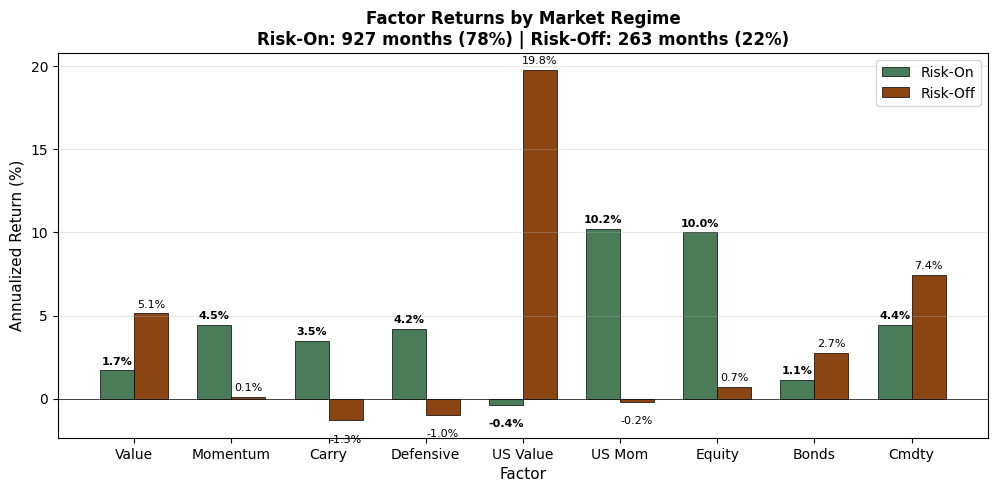

Period: 1927-2026 (1190 months)
Regime distribution: Risk-On 927 (77.9%), Risk-Off 263 (22.1%)


,Risk-On (%),Risk-Off (%)
Value,1.7,5.1
Momentum,4.5,0.1
Equity,10.0,0.7
Bonds,1.1,2.7
Carry,3.5,-1.3
Defensive,4.2,-1.0


In [24]:
def plot_factor_returns_by_regime():
    """Compare annualized factor returns between Risk-On and Risk-Off regimes."""
    # Calculate mean factor returns by regime
    regime_labels_2 = pd.Series(labels_2, index=factors_df.index, name="regime")
    factor_by_regime = factors_df.copy()
    factor_by_regime["regime"] = regime_labels_2

    # Mean returns by regime (annualized)
    regime_means = factor_by_regime.groupby("regime").mean() * 12
    regime_means.index = ["Risk-Off" if i == bad_regime else "Risk-On" for i in regime_means.index]

    # Rename columns for readability
    col_renames = {
        "All asset classes Value": "Value",
        "All asset classes Momentum": "Momentum",
        "All asset classes Carry": "Carry",
        "All asset classes Defensive": "Defensive",
        "US Stock Selection Value": "US Value",
        "US Stock Selection Momentum": "US Mom",
        "Equity indices Market": "Equity",
        "Fixed income Market": "Bonds",
        "Commodities Market": "Cmdty",
    }
    regime_means_display = regime_means.rename(columns=col_renames)

    # Create bar chart comparing regimes
    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(regime_means_display.columns))
    width = 0.35

    bars1 = ax.bar(
        x - width / 2,
        regime_means_display.loc["Risk-On"].values * 100,
        width,
        label="Risk-On",
        color="#4a7c59",
        edgecolor="black",
        linewidth=0.5,
    )
    bars2 = ax.bar(
        x + width / 2,
        regime_means_display.loc["Risk-Off"].values * 100,
        width,
        label="Risk-Off",
        color="#8b4513",
        edgecolor="black",
        linewidth=0.5,
    )

    # Add value labels
    for bar, val in zip(bars1, regime_means_display.loc["Risk-On"].values, strict=False):
        height = bar.get_height()
        ax.annotate(
            f"{val * 100:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3 if height >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=8,
            fontweight="bold",
        )

    for bar, val in zip(bars2, regime_means_display.loc["Risk-Off"].values, strict=False):
        height = bar.get_height()
        ax.annotate(
            f"{val * 100:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3 if height >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=8,
        )

    ax.set_ylabel("Annualized Return (%)", fontsize=11)
    ax.set_xlabel("Factor", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(regime_means_display.columns, fontsize=10)
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    n_on = (labels_2 == good_regime).sum()
    n_off = (labels_2 == bad_regime).sum()
    ax.set_title(
        f"Factor Returns by Market Regime\nRisk-On: {n_on} months ({n_on / len(labels_2) * 100:.0f}%) | Risk-Off: {n_off} months ({n_off / len(labels_2) * 100:.0f}%)",
        fontsize=12,
        fontweight="bold",
    )

    plt.show()

    # Display per-factor returns as a DataFrame for easy comparison.
    period_label = (
        f"{factors_df.index.min().year}-{factors_df.index.max().year} ({len(factors_df)} months)"
    )
    print(f"Period: {period_label}")
    print(
        f"Regime distribution: Risk-On {n_on} ({n_on / len(labels_2) * 100:.1f}%), "
        f"Risk-Off {n_off} ({n_off / len(labels_2) * 100:.1f}%)"
    )
    key_factors = [
        c
        for c in ["Value", "Momentum", "Equity", "Bonds", "Carry", "Defensive"]
        if c in regime_means_display.columns
    ]
    factor_summary = (regime_means_display[key_factors].T * 100).round(1)
    factor_summary.columns = [f"{c} (%)" for c in factor_summary.columns]
    return factor_summary


factor_summary = plot_factor_returns_by_regime()
factor_summary

**Interpretation**: The regime split reveals distinct factor behavior:

- **Value is countercyclical**: Returns *increase* during Risk-Off (+5.3% vs +1.6%),
  consistent with the value premium's tendency to compensate for distress risk.
- **Momentum is procyclical**: Much weaker during Risk-Off (+0.4% vs +4.5%),
  reflecting momentum's vulnerability to sharp reversals.
- **Carry and Defensive turn negative** in Risk-Off (−0.6% and −0.5%) — these
  strategies that appear safe in calm markets lose money when conditions deteriorate.
- **Bonds outperform in Risk-Off** (+4.2% vs +0.8%), consistent with the classic
  flight-to-quality effect.

For portfolio construction, this suggests Value and Bonds provide genuine
diversification during stress, while Carry and Defensive do not.

## Regime Statistics

Compare key metrics between Risk-On and Risk-Off periods.

In [25]:
def compute_regime_statistics():
    """Calculate and display comprehensive regime statistics."""
    # Calculate comprehensive regime statistics
    equity_returns = factors_df["Equity indices Market"]
    regime_series = pd.Series(labels_2, index=factors_df.index)

    regime_stats_list = []
    for regime, name in [(good_regime, "Risk-On"), (bad_regime, "Risk-Off")]:
        mask = regime_series == regime
        returns = equity_returns[mask]

        # Basic counts
        n_months = mask.sum()
        pct_time = n_months / len(mask) * 100

        # Return statistics (annualized)
        mean_ret = returns.mean() * 12
        vol = returns.std() * np.sqrt(12)
        sharpe = mean_ret / vol if vol > 0 else 0

        # Drawdown
        cum_ret = (1 + returns).cumprod()
        peak = cum_ret.cummax()
        drawdown = (cum_ret - peak) / peak
        max_dd = drawdown.min()

        regime_stats_list.append(
            {
                "Regime": name,
                "Months": n_months,
                "% of Time": pct_time,
                "Ann. Return": mean_ret,
                "Ann. Volatility": vol,
                "Sharpe Ratio": sharpe,
                "Max Drawdown": max_dd,
            }
        )

    regime_stats_df = pd.DataFrame(regime_stats_list).set_index("Regime")

    # Volatility ratio (printed; the table itself displays below).
    vol_on = regime_stats_df.loc["Risk-On", "Ann. Volatility"]
    vol_off = regime_stats_df.loc["Risk-Off", "Ann. Volatility"]
    print(f"Volatility ratio (Risk-Off / Risk-On): {vol_off / vol_on:.2f}x")
    return regime_stats_df.style.format(
        {
            "% of Time": "{:.1f}%",
            "Ann. Return": "{:+.1%}",
            "Ann. Volatility": "{:.1%}",
            "Sharpe Ratio": "{:.2f}",
            "Max Drawdown": "{:.1%}",
        }
    )


compute_regime_statistics()

Volatility ratio (Risk-Off / Risk-On): 2.26x


,Months,% of Time,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Regime,,,,,,
Risk-On,927,77.9%,+10.0%,8.6%,1.17,-24.3%
Risk-Off,263,22.1%,+0.7%,19.4%,0.04,-83.5%


**Interpretation**: The regime split is stark. Risk-On delivers a Sharpe of 1.11
while Risk-Off drops to 0.12 — equity exposure during Risk-Off is essentially
uncompensated risk. The −76.9% max drawdown in Risk-Off reflects the Great
Depression and underscores that these are not mild corrections.

The direct volatility ratio here (2.2x) is much larger than the rolling-window
average reported earlier (1.3x). The rolling measure smooths over extreme months,
while this calculation captures the full variance within each regime. The direct
measure better reflects what a portfolio actually experiences during Risk-Off.

## Regime Duration Analysis

In [26]:
# Calculate average duration
durations = {}
for regime, name in [(bad_regime, "Risk-Off"), (good_regime, "Risk-On")]:
    regime_mask = labels_2 == regime
    runs = []
    current_run = 0
    for val in regime_mask:
        if val:
            current_run += 1
        elif current_run > 0:
            runs.append(current_run)
            current_run = 0
    if current_run > 0:
        runs.append(current_run)
    durations[name] = (np.mean(runs), np.max(runs), len(runs))

transitions = int(np.sum(np.diff(labels_2) != 0))

duration_df = pd.DataFrame(
    [
        {
            "Regime": name,
            "Avg duration (months)": durations[name][0],
            "Max duration (months)": durations[name][1],
            "Episodes": durations[name][2],
        }
        for name in ["Risk-On", "Risk-Off"]
    ]
).set_index("Regime")

print(
    f"Total regime transitions: {transitions} "
    f"(avg {len(labels_2) / transitions:.1f} months between switches)"
)
duration_df.style.format({"Avg duration (months)": "{:.1f}"})

Total regime transitions: 275 (avg 4.3 months between switches)


,Avg duration (months),Max duration (months),Episodes
Regime,,,
Risk-On,6.7,110,138
Risk-Off,1.9,14,138


**Interpretation**: With 267 transitions over 98 years, the model switches regime
roughly every 4 months on average. Risk-Off episodes are short (avg ~2 months)
— they capture acute stress periods rather than prolonged bear markets. This
choppiness has practical implications: a strategy that reallocates based on these
signals would trade frequently, incurring transaction costs that may erode the
regime-timing benefit. Regime models are more useful for *understanding* market
dynamics than for high-frequency tactical allocation.

## Key Takeaways

- **BIC favors two regimes**: K=2 has the lowest BIC and highest silhouette score,
  though AIC prefers more clusters. The two-state model offers the most interpretable
  and stable regime split.
- **Regimes capture distinct risk environments**: Risk-Off has 2.2x higher volatility,
  a Sharpe of 0.12 (vs 1.11), and a max drawdown of −77%.
- **Value is countercyclical**: +5.3% annualized during Risk-Off vs +1.6% during Risk-On.
  Carry and Defensive, despite their names, turn negative in Risk-Off.
- **Momentum is procyclical**: +4.5% during Risk-On vs +0.4% during Risk-Off — weakest
  factor during market stress.
- **Regime signals are noisy**: With transitions every ~4 months on average, this model
  is better suited for understanding factor dynamics than for tactical allocation.

**Next**: `macro_regimes.py` switches from style returns to macro indicators (UNRATE,
DFF, T10Y2Y, CPIAUCSL) and validates the resulting clusters against S&P 500 volatility
and drawdowns. See Chapter 1 §1.4 for the workflow context.